# MHR kinematics: the chain, forward kinematics, and IK

**The short answer to "does MHR have a kinematic chain?": yes, an explicit one — and that is
the single biggest structural difference from SMPL.**

In SMPL/SMPL-X the joints are *regressed from the surface*: a joint-regressor matrix maps
vertices to joint centres, so the skeleton is a by-product of the mesh and the pose vector is
a flat stack of axis-angle triples with no names and no limits. In MHR the skeleton is a
first-class artist-authored articulated figure — 127 joints, an explicit parent array, bone
offsets, per-joint pre-rotations, joint limits — and the mesh hangs off it by linear blend
skinning. That means:

* **Forward kinematics** is an ordinary transform composition down the tree, and we can
  reproduce it by hand and check it against the library to ~$10^{-5}$ cm.
* **Inverse kinematics** is a well-posed least-squares problem on the rig, and `pymomentum`
  ships a batched, differentiable Levenberg–Marquardt solver (`solve_ik`) with position,
  orientation, 2D-projection, distance, plane, vertex and limit error terms.

There is one wrinkle that makes MHR unusual and is worth understanding early: the pose vector
you pass to the model is **not** the joint parameters. There are *two* levels:

$$
\underbrace{\theta_p \in \mathbb{R}^{204}}_{\text{named model parameters}}
\;\xrightarrow{\;T_p\;}\;
\underbrace{\Theta_j \in \mathbb{R}^{127 \times 7}}_{\text{joint parameters}}
\;\xrightarrow{\;\text{FK}\;}\;
\underbrace{S \in \mathbb{R}^{127 \times 8}}_{\text{world skeleton state}}
\;\xrightarrow{\;\text{LBS}\;}\;
\underbrace{X \in \mathbb{R}^{V \times 3}}_{\text{vertices}}
$$

$T_p$ is a fixed sparse linear map. Everything in this notebook is about those four arrows.

**What we cover**

| § | topic |
|---|---|
| 1 | the kinematic tree: parents, chains, depth |
| 2 | the parameter transform $T_p$ — the 204 → 127×7 indirection |
| 3 | the local joint transform, and FK written from scratch (verified) |
| 4 | pre-rotations: why `_twist` parameters twist |
| 5 | visualising the chain in 3D, with the mesh |
| 6 | FK is differentiable — the kinematic Jacobian |
| 7 | inverse kinematics with `solve_ik` |
| 8 | restricting the solve: active parameters and joint limits |
| 9 | multi-constraint IK (reach + planted feet) |
| 10 | IK from 2D keypoints — the image → pose direction |
| 11 | cheat sheet |

Run it top to bottom; it takes about a minute on CPU. We use **LOD 6** (595 vertices) throughout
because the kinematics are *identical at every LOD* — only the skinned surface changes — and LOD 6
loads in a fraction of a second with 21 MB of correctives instead of 664 MB.

## 0. Setup

In [1]:
import sys, time, pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as Rot

# Run from the repo root whether the notebook sits in the root or in "demos ipynb/".
ROOT = pathlib.Path.cwd()
if not (ROOT / "mhr_kit").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pymomentum.geometry as pmg
import pymomentum.solver as pms

from mhr_kit.model import load_mhr, faces, joint_names, parameter_names, joint_positions
from mhr_kit.params import model_parameters, pose
from mhr_kit import render

torch.set_grad_enabled(False)
plt.rcParams.update({"figure.dpi": 110, "font.size": 8, "axes.grid": False})

model = load_mhr(lod=6, device="cpu", correctives=False)
character = model.character            # the pymomentum Character: skeleton + parameter transform + mesh
skeleton  = character.skeleton
ptransform = character.parameter_transform

JOINTS = joint_names(model)            # 127 names
PARAMS = parameter_names(model)        # the first 204 names of the transform
print(f"{len(JOINTS)} joints, {len(PARAMS)} model parameters, {len(faces(model))} triangles")

127 joints, 204 model parameters, 1186 triangles


Two dictionaries make the rest of the notebook readable — never hard-code an index.

In [2]:
J = {name: i for i, name in enumerate(JOINTS)}   # joint name -> joint index
P = {name: i for i, name in enumerate(PARAMS)}   # parameter name -> column in the 204-vector

def mp(**kwargs):
    """A (1, 204) model-parameter row, set by name; everything unmentioned stays at rest."""
    return model_parameters(model, kwargs)

REST = mp()                                       # all zeros -> the T-pose
print(REST.shape, "all-zero =", bool((REST == 0).all()))

torch.Size([1, 204]) all-zero = True


## 1. The kinematic tree

The skeleton is stored the way every articulated-figure library stores one: a flat array of
joints plus a `parent` index per joint, ordered so that **a parent always precedes its
children**. That ordering is what lets forward kinematics be a single forward sweep with no
recursion and no sorting.

In [3]:
parents = np.asarray(skeleton.joint_parents)      # (127,), -1 for the root
offsets = np.asarray(skeleton.offsets)            # (127, 3) rest translation in the parent frame, cm
prerots = np.asarray(skeleton.pre_rotations)      # (127, 4) fixed xyzw quaternion per joint

# `get_child_joints` needs an explicit `recursive` flag; wrap it once.
def children(j, recursive=False):
    """Immediate child joints of `j` (or its whole subtree if recursive)."""
    return list(skeleton.get_child_joints(int(j), recursive))

print("parents[:10] =", parents[:10])
print("roots (parent == -1):", [JOINTS[i] for i in np.where(parents < 0)[0]])
print("parent index < child index for every joint:",
      bool(all(parents[i] < i for i in range(len(parents)))))

depth = np.zeros(len(parents), int)
for i in range(len(parents)):
    if parents[i] >= 0:
        depth[i] = depth[parents[i]] + 1
print("tree depth:", depth.max(),
      "| leaves:", int(sum(len(children(i)) == 0 for i in range(len(parents)))))

parents[:10] = [-1  0  1  2  3  4  5  6  7  3]
roots (parent == -1): ['body_world']
parent index < child index for every joint: True
tree depth: 15 | leaves: 56


### Walking a chain

`get_parent` walks up, `get_child_joints` walks down. The chain from a wrist to the root
*is* the kinematic chain that an arm IK solve manipulates.

In [4]:
def chain_to_root(joint):
    """Joint indices from `joint` up to the root, inclusive."""
    out, j = [], J[joint] if isinstance(joint, str) else joint
    while j >= 0:
        out.append(j)
        j = skeleton.get_parent(j)
    return out

print("l_wrist -> root :", " -> ".join(JOINTS[j] for j in chain_to_root("l_wrist")))
print()
print("l_foot -> root  :", " -> ".join(JOINTS[j] for j in chain_to_root("l_foot")))

l_wrist -> root : l_wrist -> l_wrist_twist -> l_lowarm -> l_uparm -> l_clavicle -> c_spine3 -> c_spine2 -> c_spine1 -> c_spine0 -> root -> body_world

l_foot -> root  : l_foot -> l_lowleg -> l_upleg -> root -> body_world


Notice `l_wrist_twist` sitting between `l_lowarm` and `l_wrist`. MHR inserts **fractional twist
joints** into the chain: forearm twist is split across several joints so the skin rotates
gradually instead of all at one hinge. That is what kills the "candy-wrapper" artefact that
plagues single-joint LBS forearms — and it is done in the *parameter transform* (§2), not by
asking the animator to key three joints.

### The whole tree, printed

127 joints is small enough to read. Fingers are collapsed here to keep it on one screen.

In [5]:
def print_tree(root=0, prefix="", collapse=("thumb", "index", "middle", "ring", "pinky")):
    kids = children(root)
    name = JOINTS[root]
    if any(c in name for c in collapse):
        return
    for k, kid in enumerate(kids):
        last = k == len(kids) - 1
        kname = JOINTS[kid]
        if any(c in kname for c in collapse):
            continue
        print(prefix + ("└─ " if last else "├─ ") + kname)
        print_tree(kid, prefix + ("   " if last else "│  "))

print(JOINTS[0])
print_tree(0)
n_finger = sum(any(c in n for c in ("thumb", "index", "middle", "ring", "pinky")) for n in JOINTS)
print(f"\n(+ {n_finger} finger joints, collapsed)")

body_world
└─ root
   ├─ l_upleg
   │  ├─ l_lowleg
   │  │  ├─ l_foot
   │  │  │  └─ l_talocrural
   │  │  │     └─ l_subtalar
   │  │  │        └─ l_transversetarsal
   │  │  │           └─ l_ball
   │  │  ├─ l_lowleg_twist1_proc
   │  │  ├─ l_lowleg_twist2_proc
   │  │  ├─ l_lowleg_twist3_proc
   │  │  └─ l_lowleg_twist4_proc
   │  ├─ l_upleg_twist0_proc
   │  ├─ l_upleg_twist1_proc
   │  ├─ l_upleg_twist2_proc
   │  ├─ l_upleg_twist3_proc
   │  └─ l_upleg_twist4_proc
   ├─ r_upleg
   │  ├─ r_lowleg
   │  │  ├─ r_foot
   │  │  │  └─ r_talocrural
   │  │  │     └─ r_subtalar
   │  │  │        └─ r_transversetarsal
   │  │  │           └─ r_ball
   │  │  ├─ r_lowleg_twist1_proc
   │  │  ├─ r_lowleg_twist2_proc
   │  │  ├─ r_lowleg_twist3_proc
   │  │  └─ r_lowleg_twist4_proc
   │  ├─ r_upleg_twist0_proc
   │  ├─ r_upleg_twist1_proc
   │  ├─ r_upleg_twist2_proc
   │  ├─ r_upleg_twist3_proc
   │  └─ r_upleg_twist4_proc
   └─ c_spine0
      └─ c_spine1
         └─ c_spine2
            └─ 

## 2. The parameter transform $T_p$: 204 named controls → 127×7 joint parameters

Every momentum joint carries **7 numbers**: 3 translations, 3 XYZ-Euler rotations, 1 uniform
scale. So the full articulation state is $127 \times 7 = 889$ numbers. But you never set those
directly — you set 204 *named model parameters*, and a fixed sparse matrix maps them across:

$$\Theta_j = T_p \, \theta_p, \qquad T_p \in \mathbb{R}^{889 \times 321}$$

The 321 columns are the 204 model parameters **plus** 45 identity and 72 expression
coefficients, which the same transform carries along (they do not touch the skeleton).

In [6]:
Tp = np.asarray(ptransform.transform.todense() if hasattr(ptransform.transform, "todense")
                else ptransform.transform)
print("Tp:", Tp.shape, f"| nonzeros: {np.count_nonzero(Tp)} ({100*np.count_nonzero(Tp)/Tp.size:.2f}% dense)")
print("columns 0..203 = model parameters, 204..248 = identity, 249..320 = expression")

# Named parameter subsets the library maintains for you -- indispensable for IK.
for label in ("pose_parameters", "rigid_parameters", "scaling_parameters",
              "blend_shape_parameters", "face_expression_parameters"):
    mask = np.asarray(getattr(ptransform, label))
    print(f"{label:28s} {int(mask.sum()):>4d} parameters")

Tp: (889, 321) | nonzeros: 368 (0.13% dense)
columns 0..203 = model parameters, 204..248 = identity, 249..320 = expression
pose_parameters               136 parameters
rigid_parameters                6 parameters
scaling_parameters             68 parameters
blend_shape_parameters        117 parameters
face_expression_parameters      0 parameters


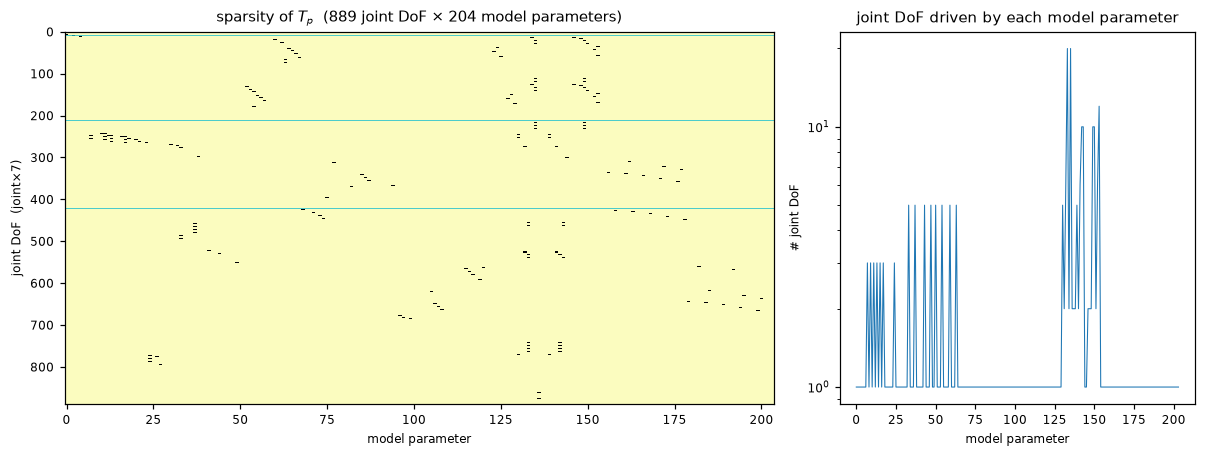

most broadly-acting parameters:
  leg_length_flexible          drives  20 joint DoF
  arm_length_flexible          drives  20 joint DoF
  scale_foot_length            drives  12 joint DoF
  scale_lowlegs                drives  10 joint DoF
  scale_uplegs                 drives  10 joint DoF
  scale_lowarms                drives  10 joint DoF


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), width_ratios=[2, 1])

ax[0].imshow(np.abs(Tp[:, :204]) > 0, aspect="auto", cmap="magma_r", interpolation="nearest")
ax[0].set(title=r"sparsity of $T_p$  (889 joint DoF $\times$ 204 model parameters)",
          xlabel="model parameter", ylabel="joint DoF  (joint$\\times$7)")
for y, lab in [(0, "root"), (7*1, "spine"), (7*30, "arms"), (7*60, "legs")]:
    ax[0].axhline(y, color="tab:cyan", lw=0.5)

per_param = (np.abs(Tp[:, :204]) > 0).sum(0)
ax[1].plot(per_param, lw=0.7)
ax[1].set(title="joint DoF driven by each model parameter", xlabel="model parameter",
          ylabel="# joint DoF", yscale="log")
plt.tight_layout(); plt.show()

print("most broadly-acting parameters:")
for i in np.argsort(-per_param)[:6]:
    print(f"  {PARAMS[i]:<28s} drives {per_param[i]:>3d} joint DoF")

The two off-diagonal structures in that plot are the whole point of the indirection:

**One parameter → many joints.** `arm_length_flexible` or `scale_uplegs` touch dozens of joint
DoF at once; `l_lowarm_twist` spreads its rotation over the fractional twist joints. Below,
one scalar drives three joints by design.

**Many parameters → one joint.** A single spine joint is driven by an overlapping mixture of
`spine_bend0`, `spine_lean0`, `spine_twist0` and the `*_flexible` residuals — so a coarse
"bend the spine" control and a fine per-joint correction coexist in the same vector.

In [8]:
def driven_joints(param):
    rows = np.where(np.abs(Tp[:, P[param]]) > 0)[0]
    return sorted({(r // 7) for r in rows})

def driving_params(joint, dof=None):
    j = J[joint]
    rows = range(7*j, 7*j + 7) if dof is None else [7*j + dof]
    cols = np.where(np.abs(Tp[np.ix_(list(rows), range(204))]).sum(0) > 0)[0]
    return [PARAMS[c] for c in cols]

print("one -> many:  'l_lowarm_twist' drives")
for j in driven_joints("l_lowarm_twist"):
    w = Tp[7*j + 3, P["l_lowarm_twist"]]       # dof 3 = rotation about x
    print(f"    {JOINTS[j]:<18s} rx weight {w:+.3f}")

print("\nmany -> one:  joint 'c_spine1' is driven by")
print("   ", driving_params("c_spine1"))

print("\nparameters that move the left arm chain:")
arm = [J[n] for n in ("l_clavicle", "l_uparm", "l_lowarm", "l_wrist_twist", "l_wrist")]
mask = np.asarray(ptransform.parameters_for_joints(arm))
print("   ", [PARAMS[i] for i in np.where(mask[:204])[0]])

one -> many:  'l_lowarm_twist' drives
    l_wrist_twist      rx weight +1.000
    l_lowarm_twist1_proc rx weight +0.200
    l_lowarm_twist2_proc rx weight +0.400
    l_lowarm_twist3_proc rx weight +0.600
    l_lowarm_twist4_proc rx weight +0.800

many -> one:  joint 'c_spine1' is driven by
    ['spine_twist0', 'spine_lean0', 'spine_bend0', 'spine1_rx_flexible', 'spine_twist1', 'spine1_ry_flexible', 'spine_lean1', 'spine1_rz_flexible', 'spine_bend1', 'spine_length_flexible', 'scale_spine_length']

parameters that move the left arm chain:
    ['l_clavicle_rx', 'l_clavicle_ry', 'l_clavicle_rz', 'l_uparm_twist', 'l_uparm_ry', 'l_uparm_rz', 'l_elbow_bend', 'l_lowarm_twist', 'l_wrist_ry', 'l_wrist_rz', 'shoulder_width_flexible', 'arm_length_flexible', 'scale_shoulder_width', 'scale_uparms', 'scale_lowarms', 'scale_l_hands']


`parameters_for_joints` is the function to remember: give it a chain and it returns the
boolean mask of parameters that can move it. That mask is exactly what you feed to
`solve_ik(active_parameters=...)` in §8 to stop an arm reach from bending the spine.

### Applying the transform

`ptransform.apply` performs $\Theta_j = T_p \theta_p$. The result reshapes to `(127, 7)`.

In [9]:
theta_p = np.zeros(ptransform.size, dtype=np.float32)      # 321: model + identity + expression
theta_p[P["l_elbow_bend"]] = 1.2
theta_p[P["l_lowarm_twist"]] = 0.8

Theta_j = np.asarray(ptransform.apply(theta_p)).reshape(-1, 7)
print("joint parameters:", Theta_j.shape, "  columns = (tx, ty, tz, rx, ry, rz, scale)")

nz = np.where(np.abs(Theta_j).sum(1) > 0)[0]
print("\njoints with a non-rest parameter:")
for j in nz:
    print(f"  {JOINTS[j]:<18s} t={Theta_j[j,:3].round(3)}  r={Theta_j[j,3:6].round(3)}  s={Theta_j[j,6]:.3f}")

joint parameters: (127, 7)   columns = (tx, ty, tz, rx, ry, rz, scale)

joints with a non-rest parameter:
  l_lowarm           t=[0. 0. 0.]  r=[0.  0.  1.2]  s=0.000
  l_wrist_twist      t=[0. 0. 0.]  r=[0.8 0.  0. ]  s=0.000
  l_lowarm_twist1_proc t=[0. 0. 0.]  r=[0.16 0.   0.  ]  s=0.000
  l_lowarm_twist2_proc t=[0. 0. 0.]  r=[0.32 0.   0.  ]  s=0.000
  l_lowarm_twist3_proc t=[0. 0. 0.]  r=[0.48 0.   0.  ]  s=0.000
  l_lowarm_twist4_proc t=[0. 0. 0.]  r=[0.64 0.   0.  ]  s=0.000


## 3. The local joint transform, and forward kinematics from scratch

Each joint's transform **from its own frame to its parent's frame** is, in order:

$$
L_j \;=\; \underbrace{T\big(\mathrm{offset}_j + t_j\big)}_{\text{bone, plus animated translation}}
\;\cdot\;
\underbrace{R^{\text{pre}}_j}_{\substack{\text{fixed pre-rotation}\\ \text{(aligns } x \text{ with the bone)}}}
\;\cdot\;
\underbrace{R_{xyz}(r_j)}_{\text{animated Euler XYZ}}
\;\cdot\;
\underbrace{S\big(2^{\,s_j}\big)}_{\text{uniform scale}}
$$

and world transforms come from one sweep down the (parent-before-child) array:

$$W_j = W_{\mathrm{parent}(j)} \cdot L_j, \qquad W_{\text{root}} = L_{\text{root}}$$

Three details are easy to get wrong and each one silently breaks a fit:

1. **The offset is inside the translation, before the rotation.** The bone vector lives in the
   parent frame, so a joint's rotation moves its *children*, never itself.
2. **The pre-rotation is applied before the animated Euler angles**, and is fixed per joint.
3. **Scale is $2^{s}$, not $s$ or $e^{s}$** — so $s=0$ means unit scale and $s=1$ doubles the
   limb. Getting the base wrong gives a plausible-looking but wrong body.

Let's write it out and check against the library.

In [10]:
def forward_kinematics(theta_p):
    """Compose local transforms down the tree. Returns (127, 4, 4) world matrices."""
    Theta = np.asarray(ptransform.apply(np.asarray(theta_p, np.float32))).reshape(-1, 7)
    W = np.zeros((len(parents), 4, 4))
    for j in range(len(parents)):
        t = offsets[j] + Theta[j, :3]                                    # 1. bone + translation
        R = Rot.from_quat(prerots[j]) * Rot.from_euler("xyz", Theta[j, 3:6])   # 2. pre-rot, then Euler
        s = 2.0 ** Theta[j, 6]                                          # 3. scale is a power of two
        L = np.eye(4)
        L[:3, :3] = R.as_matrix() * s
        L[:3, 3] = t
        W[j] = L if parents[j] < 0 else W[parents[j]] @ L
    return W

# A pose that exercises rotations, translation and scale simultaneously.
probe = np.zeros(ptransform.size, np.float32)
for name, value in {"l_elbow_bend": 1.1, "r_uparm_rz": -0.7, "spine_bend0": 0.35,
                    "root_ry": 0.6, "root_tx": 1.5, "scale_uplegs": 0.25,
                    "l_knee_bend": 0.9, "head_twist": -0.4}.items():
    probe[P[name]] = value

W_mine = forward_kinematics(probe)
S_lib  = pmg.model_parameters_to_skeleton_state(character, probe)   # (127, 8) world tx ty tz qx qy qz qw s

err_pos = np.abs(W_mine[:, :3, 3] - S_lib[:, :3]).max()
print(f"max joint-position disagreement with pymomentum: {err_pos:.2e} cm")
assert err_pos < 1e-3, "FK identity broken"
print("→ forward kinematics reproduced exactly.")

max joint-position disagreement with pymomentum: 2.95e-05 cm
→ forward kinematics reproduced exactly.


### The skeleton state that MHR actually hands you

`model(...)` returns a `(B, 127, 8)` **skeleton state**: `tx ty tz | qx qy qz qw | scale`, all
**world-space**, so `joint_positions()` is a plain slice — no FK needed on your side. It is the
same thing `model_parameters_to_skeleton_state` computes, just batched and inside the module.

In [11]:
identity = torch.zeros(1, 45)
params = torch.tensor(probe[None, :204])
vertices, skel_state = model(identity, params, None)

print("vertices     ", tuple(vertices.shape),   "cm, +y up, +z forward")
print("skel_state   ", tuple(skel_state.shape), "world (tx,ty,tz, qx,qy,qz,qw, s)")

pos_model = joint_positions(skel_state)[0].numpy()
print(f"\nagrees with our FK to {np.abs(pos_model - W_mine[:, :3, 3]).max():.2e} cm")

# Rotations too -- compare as matrices to dodge the quaternion sign ambiguity.
q = skel_state[0, :, 3:7].numpy()
R_model = Rot.from_quat(q).as_matrix()
R_mine  = W_mine[:, :3, :3] / np.linalg.norm(W_mine[:, :3, :3], axis=1, keepdims=True).clip(1e-9)
print(f"rotation disagreement: {np.abs(R_model - R_mine).max():.2e}")

vertices      (1, 595, 3) cm, +y up, +z forward
skel_state    (1, 127, 8) world (tx,ty,tz, qx,qy,qz,qw, s)

agrees with our FK to 8.62e-06 cm
rotation disagreement: 8.78e-08


## 4. Pre-rotations: why `_twist` parameters twist

$R^{\text{pre}}_j$ is a fixed rotation that aligns each joint's **local $x$ axis with its bone**.
That single convention is why the parameter names mean what they say:

* rotation about $x$ = **twist along the bone** (hence `l_uparm_twist`, `spine_twist0`);
* the other two axes are the anatomically symmetric swing directions, and because the
  pre-rotations are mirrored left/right, **the same sign gives the same anatomical motion on
  both sides** — `l_uparm_rz` and `r_uparm_rz` both raise their arm.

The measurable consequence: rotating a joint about $x$ moves its *child* barely at all (it spins
in place) while rotating about $y$ or $z$ swings the child through an arc.

In [12]:
def child_travel(param, angle=0.6):
    """How far the driven joint's first child moves, per axis of rotation."""
    js = driven_joints(param)
    j = js[0]
    kids = children(j)
    if not kids:
        return None
    kid = kids[0]
    p0 = pmg.model_parameters_to_skeleton_state(character, np.zeros(ptransform.size, np.float32))[kid, :3]
    v = np.zeros(ptransform.size, np.float32); v[P[param]] = angle
    p1 = pmg.model_parameters_to_skeleton_state(character, v)[kid, :3]
    return JOINTS[j], JOINTS[kid], float(np.linalg.norm(p1 - p0))

print(f"{'parameter':<20s} {'joint':<14s} {'child':<14s}  child travel @ 0.6 rad")
for param in ("l_uparm_twist", "l_uparm_ry", "l_uparm_rz", "spine_twist0", "spine_bend0"):
    j, kid, d = child_travel(param)
    print(f"{param:<20s} {j:<14s} {kid:<14s}  {d:6.2f} cm")

# Bone direction in the joint's own frame -- should be ~ +x everywhere.
W0 = forward_kinematics(np.zeros(ptransform.size, np.float32))
bones = []
for j in range(len(parents)):
    kids = children(j)
    if not kids or np.linalg.norm(offsets[kids[0]]) < 1e-6:
        continue
    d = offsets[kids[0]] / np.linalg.norm(offsets[kids[0]])
    bones.append(np.abs(Rot.from_quat(prerots[kids[0]]).apply(d)))
bones = np.array(bones)
print(f"\nmean |bone direction| in the child's pre-rotated frame: {bones.mean(0).round(3)}"
      "   (x dominant -> x is the twist axis)")

parameter            joint          child           child travel @ 0.6 rad
l_uparm_twist        l_uparm        l_lowarm          0.03 cm
l_uparm_ry           l_uparm        l_lowarm         15.18 cm
l_uparm_rz           l_uparm        l_lowarm         15.18 cm
spine_twist0         c_spine0       c_spine1          0.01 cm
spine_bend0          c_spine0       c_spine1          1.06 cm

mean |bone direction| in the child's pre-rotated frame: [0.849 0.181 0.14 ]   (x dominant -> x is the twist axis)


## 5. Visualising the chain

A skeleton drawing is just the world positions plus one line segment per parent→child pair.
Below: the rest pose, a posed body, and the same pose with the left-arm chain highlighted and
overlaid on the skinned mesh — so you can see the surface following the chain.

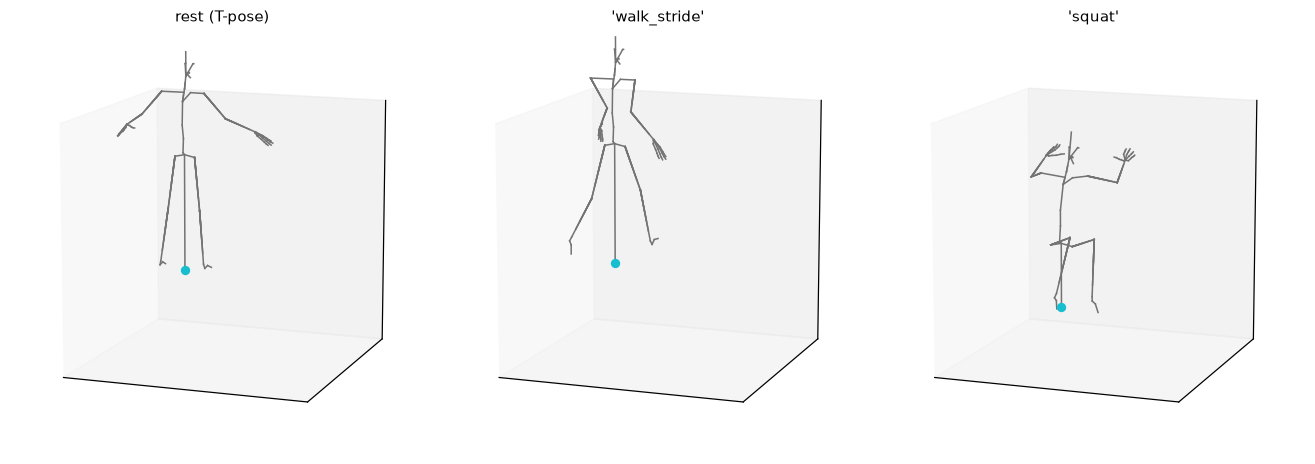

In [13]:
def draw_skeleton(ax, positions, highlight=(), title="", elev=12, azim=-70, lims=None):
    """positions: (127, 3) world cm, MHR axes (+y up, +z forward)."""
    hl = set(highlight)
    for j, p in enumerate(parents):
        if p < 0:
            continue
        a, b = positions[p], positions[j]
        on = j in hl or p in hl
        ax.plot(*zip(a, b), color="tab:orange" if on else "0.45",
                lw=2.4 if on else 1.0, zorder=3 if on else 2)
    if hl:
        ax.scatter(*positions[sorted(hl)].T, s=18, color="tab:orange", zorder=4)
    ax.scatter(*positions[[0]].T, s=26, color="tab:cyan", zorder=4)
    ax.set(title=title, xticks=[], yticks=[], zticks=[])
    c = positions.mean(0); r = float(np.abs(positions - c).max()) * 1.05
    lo, hi = c - r, c + r
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)

def positions_for(params_204):
    """(127, 3) world joint positions from a (1, 204) parameter row."""
    _, ss = model(identity, torch.as_tensor(params_204, dtype=torch.float32), None)
    return joint_positions(ss)[0].numpy()

# matplotlib's 3D axes are z-up; MHR is y-up, so we plot (x, z, y).
def yup(p):
    return np.stack([p[:, 0], p[:, 2], p[:, 1]], 1)

poses = {"rest (T-pose)": REST, "'walk_stride'": pose(model, "walk_stride"), "'squat'": pose(model, "squat")}
fig = plt.figure(figsize=(12, 4.4))
for k, (label, prm) in enumerate(poses.items()):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    draw_skeleton(ax, yup(positions_for(prm)), title=label)
plt.tight_layout(); plt.show()

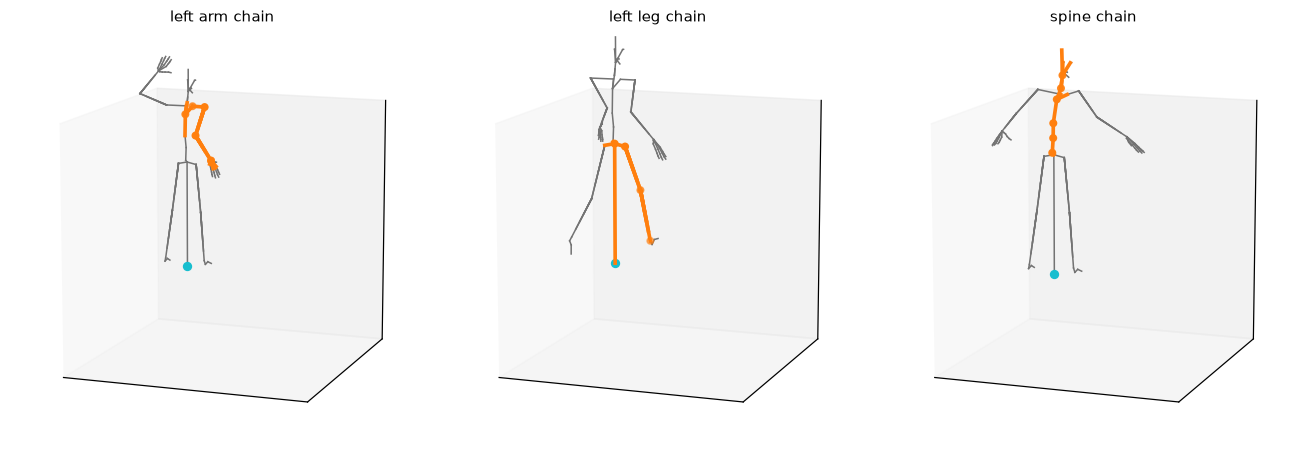

In [14]:
arm_chain = chain_to_root("l_wrist")[:6]          # wrist up to the clavicle
leg_chain = chain_to_root("l_foot")[:4]

fig = plt.figure(figsize=(12, 4.6))
for k, (label, chain, prm) in enumerate([
        ("left arm chain", arm_chain, pose(model, "wave")),
        ("left leg chain", leg_chain, pose(model, "walk_stride")),
        ("spine chain", [J[n] for n in JOINTS if n.startswith("c_spine")] + [J["c_neck"], J["c_head"]],
         mp(spine_bend0=0.5, spine_twist0=0.4, neck_bend=-0.3))]):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    draw_skeleton(ax, yup(positions_for(prm)), highlight=chain, title=label)
plt.tight_layout(); plt.show()

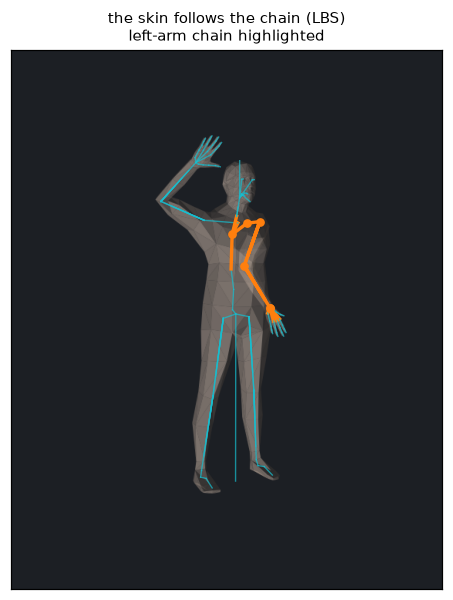

In [15]:
# Skeleton and skin together: render the mesh, then project the chain into the same image.
prm = pose(model, "wave")
verts, ss = model(identity, prm, None)
mesh = verts[0].numpy()
cam = render.orbit_camera(mesh, azimuth=32, elevation=6, size=(560, 700))
image = render.render(mesh, faces(model), cam, alpha=0.55)

pos = joint_positions(ss)[0].numpy()
uv, _ = cam.project(pos)

fig, ax = plt.subplots(figsize=(4.4, 5.5))
ax.imshow(image)
for j, p in enumerate(parents):
    if p < 0:
        continue
    on = j in set(arm_chain) or p in set(arm_chain)
    ax.plot(*zip(uv[p], uv[j]), color="tab:orange" if on else "tab:cyan",
            lw=2.2 if on else 0.9, alpha=1.0 if on else 0.7)
ax.scatter(*uv[arm_chain].T, s=22, color="tab:orange", zorder=5)
ax.set(title="the skin follows the chain (LBS)\nleft-arm chain highlighted", xticks=[], yticks=[])
plt.tight_layout(); plt.show()

## 6. Forward kinematics is differentiable — the kinematic Jacobian

The whole model is a `torch.nn.Module`, so FK (and skinning, and the correctives) are
autograd-traceable. The Jacobian $\partial p_{\text{joint}} / \partial \theta_p$ is the classic
IK Jacobian, and reading it tells you *which controls can move a given joint and how strongly* —
useful for debugging a fit that will not converge.

J = d(l_wrist position)/d(theta): (3, 204)
38 of 204 parameters can move the left wrist at all

  spine3_ry_flexible             59.14 cm / rad
  root_rz                        57.21 cm / rad
  spine2_rx_flexible             56.82 cm / rad
  spine0_rx_flexible             56.63 cm / rad
  spine0_ry_flexible             56.38 cm / rad
  spine3_rx_flexible             56.29 cm / rad
  spine1_rx_flexible             56.18 cm / rad
  root_ry                        55.57 cm / rad
  spine2_ry_flexible             54.29 cm / rad
  spine1_ry_flexible             54.24 cm / rad


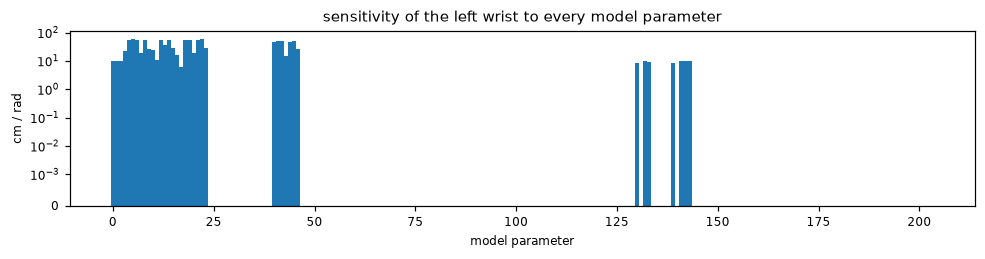

In [16]:
with torch.enable_grad():
    target_joint = J["l_wrist"]
    jac = torch.autograd.functional.jacobian(
        lambda t: joint_positions(model(identity, t, None)[1])[0, target_joint],
        REST.clone(), vectorize=True).reshape(3, 204)

sens = jac.norm(dim=0).numpy()          # cm of wrist motion per radian of each parameter
print(f"J = d(l_wrist position)/d(theta): {tuple(jac.shape)}")
print(f"{int((sens > 1e-4).sum())} of 204 parameters can move the left wrist at all\n")
for i in np.argsort(-sens)[:10]:
    print(f"  {PARAMS[i]:<28s} {sens[i]:7.2f} cm / rad")

fig, ax = plt.subplots(figsize=(9, 2.4))
ax.bar(range(204), sens, width=1.0)
ax.set_yscale("symlog", linthresh=1e-3)
ax.set(xlabel="model parameter", ylabel="cm / rad",
       title="sensitivity of the left wrist to every model parameter")
plt.tight_layout(); plt.show()

The plot is a *sparsity pattern of influence*: the root block, the spine, and the left-arm block
light up; the right arm, both legs and all the fingers are exactly zero. Note the root and spine
have **larger** lever arms on the wrist than the elbow does — which is precisely why an
unconstrained IK solve prefers to lean the whole body rather than bend the arm (§8).

## 7. Inverse kinematics with `solve_ik`

Forward is a function; inverse is an optimisation. `pymomentum.solver.solve_ik` minimises a sum
of squared residuals over the model parameters with Levenberg–Marquardt:

$$\theta^\star = \arg\min_{\theta} \; \sum_i w_i \left\| r_i(\theta) \right\|^2$$

It is **batched** (solve many frames or many people at once), **differentiable** (you can
backprop through the solve), and takes a menu of error-function types. The one you need 90% of
the time is `Position`: a 3D world-space target attached to a joint, optionally with a local
offset so the target can be a point on a bone rather than the joint itself.

Every constraint family follows the same four-tensor shape:

| tensor | shape | meaning |
|---|---|---|
| `*_parents` | `(B, N)` int | which joint the constraint hangs off |
| `*_offsets` | `(B, N, 3)` | the point in that joint's local frame |
| `*_targets` | `(B, N, 3)` | the world-space goal |
| `*_weights` | `(B, N)` | per-constraint weight |

In [17]:
def solve(targets, active, init=None, max_iter=60, weights=None, extra=None):
    """targets: {joint name: (3,) world cm}. Returns (1, 321) model parameters."""
    js = torch.tensor([[J[n] for n in targets]], dtype=torch.int32)
    tg = torch.tensor([[list(v) for v in targets.values()]], dtype=torch.float32)
    wt = torch.ones(1, len(targets)) if weights is None else torch.tensor([weights], dtype=torch.float32)
    kwargs = dict(
        character=character,
        active_parameters=active,
        model_parameters_init=torch.zeros(1, ptransform.size) if init is None else init,
        active_error_functions=[pms.ErrorFunctionType.Position],
        error_function_weights=torch.ones(1, 1),
        position_cons_parents=js,
        position_cons_offsets=torch.zeros(1, len(targets), 3),
        position_cons_weights=wt,
        position_cons_targets=tg,
        options=pms.SolverOptions(max_iter=max_iter),
    )
    if extra:
        kwargs.update(extra)
    return pms.solve_ik(**kwargs)

def reached(theta, targets):
    """Per-target residual in cm."""
    ss = pmg.model_parameters_to_skeleton_state(character, np.asarray(theta[0], np.float32))
    return {n: float(np.linalg.norm(ss[J[n], :3] - np.asarray(v))) for n, v in targets.items()}

pose_params = torch.as_tensor(ptransform.pose_parameters).clone()      # 136 pose DoF, no scaling
rest_pos = positions_for(REST)
goal = {"l_wrist": rest_pos[J["l_wrist"]] + np.array([-8.0, -25.0, 30.0])}

t0 = time.time()
theta_free = solve(goal, active=pose_params)
print(f"solve: {1000*(time.time()-t0):.1f} ms   residual: "
      f"{reached(theta_free, goal)['l_wrist']:.4f} cm")

solve: 10.9 ms   residual: 0.0000 cm


Sub-millimetre in ~10 ms on one CPU core. But look at *how* it got there:

In [18]:
moved = np.where(np.abs(theta_free[0, :204].numpy()) > 0.02)[0]
print(f"{len(moved)} parameters moved to reach one wrist target:")
for i in moved[:18]:
    print(f"  {PARAMS[i]:<28s} {theta_free[0, i]:+.3f}")
print("  ...")

26 parameters moved to reach one wrist target:
  root_tx                      +0.028
  root_ty                      -0.031
  root_tz                      +0.040
  root_rx                      +0.099
  root_ry                      -0.073
  root_rz                      -0.134
  spine0_rx_flexible           -0.058
  spine_twist0                 -0.020
  spine0_ry_flexible           -0.134
  spine_lean0                  -0.050
  spine0_rz_flexible           +0.100
  spine_bend0                  +0.038
  spine1_rx_flexible           -0.063
  spine_twist1                 -0.038
  spine1_ry_flexible           -0.100
  spine1_rz_flexible           +0.051
  spine2_rx_flexible           -0.054
  spine2_ry_flexible           -0.061
  ...


It leaned the whole body — root translation, root rotation, the entire spine. Mathematically
correct (204 unknowns, 3 equations: wildly underdetermined) and usually not what you want.
Fixing it is the subject of the next section.

## 8. Constraining the solve: active parameters and joint limits

Two levers, and MHR gives you both because the rig is explicit:

1. **`active_parameters`** — a boolean mask over the 321 columns. Only these are optimised.
   Combined with `parameters_for_joints`, "solve the arm, freeze everything else" is one line.
2. **`ErrorFunctionType.Limit`** — a soft penalty pulling the solution back inside the rig's
   authored joint limits (198 `MinMax` limits ship with MHR). Without it, IK will happily
   dislocate a shoulder to hit a target.

In [19]:
arm_only = torch.as_tensor(ptransform.parameters_for_joints(arm_chain)).clone()
arm_only &= torch.as_tensor(ptransform.pose_parameters)      # drop the scale_* block
print(f"active: {int(arm_only.sum())} (arm chain) vs {int(pose_params.sum())} (all pose DoF)")
print("   ", [PARAMS[i] for i in np.where(arm_only.numpy()[:204])[0]])

theta_arm = solve(goal, active=arm_only)
print(f"\nresidual: {reached(theta_arm, goal)['l_wrist']:.4f} cm")
print("root parameters moved:",
      {PARAMS[i]: round(float(theta_arm[0, i]), 4) for i in range(6)})

# GOTCHA: the `*_length_flexible` / `*_width_flexible` bone-length controls are counted as
# POSE parameters, not scaling parameters -- so an "arm only" mask still lets the solver
# lengthen the arm to reach a target. For a pure rotational solve, drop them explicitly.
rotations_only = arm_only.clone()
for i, name in enumerate(PARAMS):
    if name.endswith("_flexible") and ("length" in name or "width" in name):
        rotations_only[i] = False
print(f"\nrotations only: {int(rotations_only.sum())} parameters")
print("   ", [PARAMS[i] for i in np.where(rotations_only.numpy()[:204])[0]])

active: 19 (arm chain) vs 136 (all pose DoF)
    ['spine_twist1', 'spine_lean1', 'spine_bend1', 'spine3_rx_flexible', 'spine3_ry_flexible', 'spine3_rz_flexible', 'l_clavicle_rx', 'l_clavicle_ry', 'l_clavicle_rz', 'l_uparm_twist', 'l_uparm_ry', 'l_uparm_rz', 'l_elbow_bend', 'l_lowarm_twist', 'l_wrist_ry', 'l_wrist_rz', 'spine_length_flexible', 'shoulder_width_flexible', 'arm_length_flexible']

residual: 0.0000 cm
root parameters moved: {'root_tx': 0.0, 'root_ty': 0.0, 'root_tz': 0.0, 'root_rx': 0.0, 'root_ry': 0.0, 'root_rz': 0.0}

rotations only: 16 parameters
    ['spine_twist1', 'spine_lean1', 'spine_bend1', 'spine3_rx_flexible', 'spine3_ry_flexible', 'spine3_rz_flexible', 'l_clavicle_rx', 'l_clavicle_ry', 'l_clavicle_rz', 'l_uparm_twist', 'l_uparm_ry', 'l_uparm_rz', 'l_elbow_bend', 'l_lowarm_twist', 'l_wrist_ry', 'l_wrist_rz']


In [20]:
# The authored limits, unpacked. The accessor is nested: `limit.data.minmax` gives a
# LimitMinMax with `.model_parameter_index`, `.min`, `.max`.
BOUNDS = {}
for limit in character.parameter_limits:
    minmax = limit.data.minmax
    if minmax is not None:
        BOUNDS[minmax.model_parameter_index] = (minmax.min, minmax.max)
print(f"{len(character.parameter_limits)} authored limits, {len(BOUNDS)} of them MinMax")
for name in ("l_elbow_bend", "l_knee_bend", "l_clavicle_rz", "l_uparm_rz"):
    lo, hi = BOUNDS[P[name]]
    print(f"   {name:<16s} [{lo:+.2f}, {hi:+.2f}] rad")

def solve_with_limits(targets, active, limit_weight=5.0, max_iter=100):
    js = torch.tensor([[J[n] for n in targets]], dtype=torch.int32)
    tg = torch.tensor(np.array([list(v) for v in targets.values()], np.float32))[None]
    return pms.solve_ik(
        character=character, active_parameters=active,
        model_parameters_init=torch.zeros(1, ptransform.size),
        active_error_functions=[pms.ErrorFunctionType.Position, pms.ErrorFunctionType.Limit],
        error_function_weights=torch.tensor([[1.0, limit_weight]]),
        position_cons_parents=js, position_cons_offsets=torch.zeros(1, len(targets), 3),
        position_cons_weights=torch.ones(1, len(targets)), position_cons_targets=tg,
        options=pms.SolverOptions(max_iter=max_iter))

# A target the arm cannot reach by rotation alone: the solver must strain somewhere.
far = {"l_wrist": rest_pos[J["l_wrist"]] + np.array([-30.0, -35.0, 45.0])}
no_lim   = solve(far, active=rotations_only, max_iter=100)
with_lim = solve_with_limits(far, active=rotations_only)

def violations(theta):
    out = []
    for i in np.where(rotations_only.numpy()[:204])[0]:
        if i not in BOUNDS:
            continue
        lo, hi = BOUNDS[i]
        v = float(theta[0, i])
        if v < lo - 1e-3 or v > hi + 1e-3:
            out.append((PARAMS[i], v, lo, hi))
    return out

print(f"\n{'parameter':<18s} {'no limits':>10s} {'with limits':>12s}   authored range")
for i in np.where(rotations_only.numpy()[:204])[0]:
    lo, hi = BOUNDS.get(i, (np.nan, np.nan))
    print(f"{PARAMS[i]:<18s} {float(no_lim[0,i]):>10.3f} {float(with_lim[0,i]):>12.3f}"
          f"   [{lo:+.2f}, {hi:+.2f}]")

print("\nlimit violations without the Limit term:")
for name, v, lo, hi in violations(no_lim):
    print(f"   {name:<18s} {v:+.2f}  outside [{lo:+.2f}, {hi:+.2f}]")
print("limit violations with it:")
for name, v, lo, hi in violations(with_lim):
    print(f"   {name:<18s} {v:+.2f}  outside [{lo:+.2f}, {hi:+.2f}]   (soft constraint: small overshoot)")

print(f"\nresidual without limits: {reached(no_lim, far)['l_wrist']:6.2f} cm  (dislocated shoulder)")
print(f"residual with limits:    {reached(with_lim, far)['l_wrist']:6.2f} cm  "
      "(worse fit, plausible body -- the trade you want)")

198 authored limits, 198 of them MinMax
   l_elbow_bend     [-0.50, +2.00] rad
   l_knee_bend      [+0.00, +2.80] rad
   l_clavicle_rz    [-0.30, +0.30] rad
   l_uparm_rz       [-1.20, +2.00] rad

parameter           no limits  with limits   authored range
spine_twist1           -0.218       -0.900   [-0.90, +0.90]
spine_lean1            -0.513       -0.700   [-0.70, +0.70]
spine_bend1             1.210        1.500   [-0.50, +1.50]
spine3_rx_flexible     -0.286       -0.000   [+0.00, +0.00]
spine3_ry_flexible     -0.544       -0.000   [+0.00, +0.00]
spine3_rz_flexible      0.305        0.000   [+0.00, +0.00]
l_clavicle_rx          -0.516        0.000   [-0.00, +0.00]
l_clavicle_ry           0.011       -0.001   [-0.00, +0.50]
l_clavicle_rz           1.046        0.302   [-0.30, +0.30]
l_uparm_twist          -0.193       -0.012   [-1.50, +1.80]
l_uparm_ry              0.873        0.269   [-1.00, +1.20]
l_uparm_rz              0.225        0.542   [-1.20, +2.00]
l_elbow_bend           

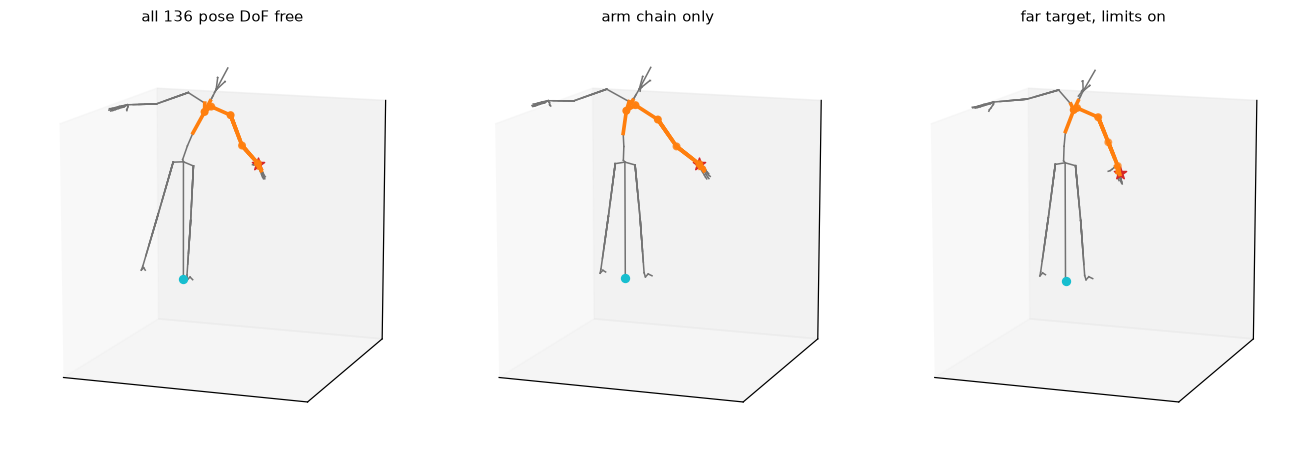

red star = the target


In [21]:
fig = plt.figure(figsize=(12, 4.6))
for k, (label, theta) in enumerate([("all 136 pose DoF free", theta_free),
                                    ("arm chain only", theta_arm),
                                    ("far target, limits on", with_lim)]):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    p = positions_for(theta[:, :204])
    draw_skeleton(ax, yup(p), highlight=arm_chain, title=label)
    tgt = (goal if k < 2 else far)["l_wrist"]
    ax.scatter([tgt[0]], [tgt[2]], [tgt[1]], s=70, marker="*", color="tab:red", zorder=6)
plt.tight_layout(); plt.show()
print("red star = the target")

## 9. Multi-constraint IK: reach without lifting your feet

Real IK problems stack constraints. Here: reach a target with the right hand, while both ankles
stay planted and the head stays upright. All position constraints, different weights — a heavier
weight means "violate this last".

  r_wrist      0.00 cm
  l_foot       0.00 cm
  r_foot       0.00 cm
  c_head       0.00 cm


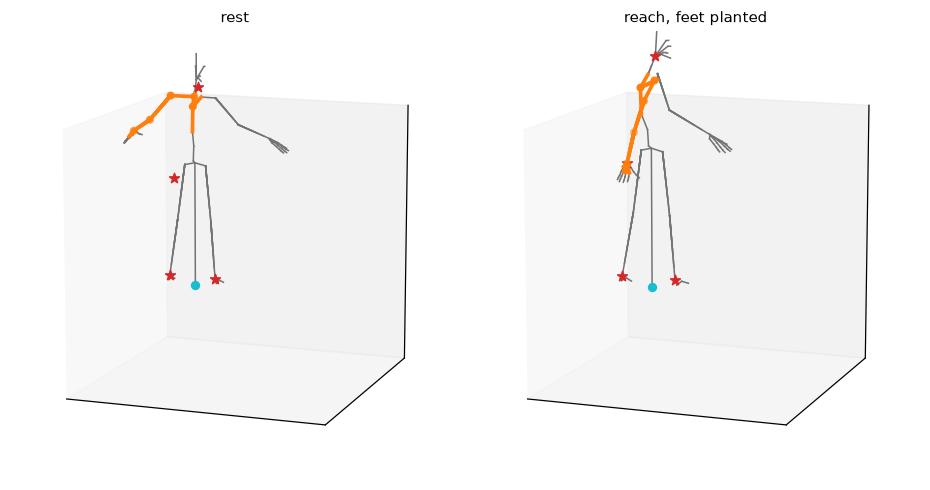

In [22]:
targets = {
    "r_wrist": rest_pos[J["r_wrist"]] + np.array([10.0, -45.0, 55.0]),   # reach down and forward
    "l_foot":  rest_pos[J["l_foot"]],                                    # planted (the ankle joint)
    "r_foot":  rest_pos[J["r_foot"]],                                    # planted
    "c_head":  rest_pos[J["c_head"]] + np.array([0.0, -6.0, 4.0]),       # allowed to dip a little
}
weights = [1.0, 20.0, 20.0, 3.0]

theta_multi = solve(targets, active=pose_params, weights=weights, max_iter=100)
for name, residual in reached(theta_multi, targets).items():
    print(f"  {name:<10s} {residual:6.2f} cm")

fig = plt.figure(figsize=(8.5, 4.6))
for k, (label, theta) in enumerate([("rest", REST), ("reach, feet planted", theta_multi[:, :204])]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    draw_skeleton(ax, yup(positions_for(theta)),
                  highlight=chain_to_root("r_wrist")[:6], title=label)
    for name in targets:
        t = targets[name]
        ax.scatter([t[0]], [t[2]], [t[1]], s=45, marker="*", color="tab:red", zorder=6)
plt.tight_layout(); plt.show()

### Batched IK

`solve_ik` broadcasts: pass `(B, N, 3)` targets and one `(B, 321)` init and you solve B problems
in one call, in parallel across threads. This is how you fit a whole video, or a whole dataset.

24 solves in 4 ms (0.2 ms each), max residual 0.0000 cm


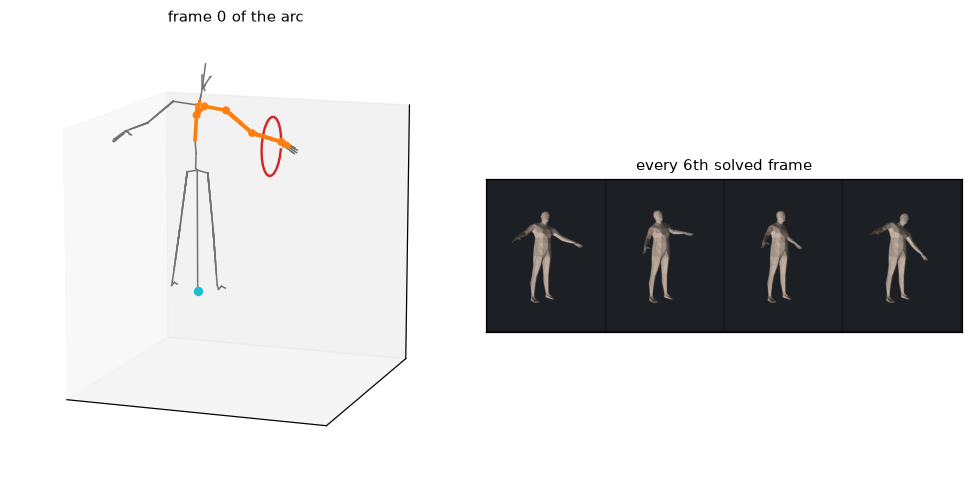

In [23]:
B = 24
angles = np.linspace(0, 2*np.pi, B, endpoint=False)
ring = rest_pos[J["l_wrist"]] + np.stack(
    [np.zeros(B), 22*np.sin(angles), 22*np.cos(angles)], 1)          # a circle the hand traces

t0 = time.time()
batched = pms.solve_ik(
    character=character,
    active_parameters=arm_only,
    model_parameters_init=torch.zeros(B, ptransform.size),
    active_error_functions=[pms.ErrorFunctionType.Position],
    error_function_weights=torch.ones(B, 1),
    position_cons_parents=torch.full((B, 1), J["l_wrist"], dtype=torch.int32),
    position_cons_offsets=torch.zeros(B, 1, 3),
    position_cons_weights=torch.ones(B, 1),
    position_cons_targets=torch.tensor(ring, dtype=torch.float32)[:, None],
)
dt = time.time() - t0
res = [np.linalg.norm(pmg.model_parameters_to_skeleton_state(character, np.asarray(batched[i], np.float32))[J["l_wrist"], :3] - ring[i])
       for i in range(B)]
print(f"{B} solves in {1000*dt:.0f} ms ({1000*dt/B:.1f} ms each), "
      f"max residual {max(res):.4f} cm")

# The solved trajectory, and one frame of it rendered.
traj = np.array([positions_for(batched[i:i+1, :204])[J["l_wrist"]] for i in range(B)])
fig = plt.figure(figsize=(9, 4.4))
ax = fig.add_subplot(1, 2, 1, projection="3d")
draw_skeleton(ax, yup(positions_for(batched[0:1, :204])), highlight=arm_chain, title="frame 0 of the arc")
ax.plot(traj[:, 0], traj[:, 2], traj[:, 1], color="tab:red", lw=1.6)
ax2 = fig.add_subplot(1, 2, 2)
verts_b, _ = model(identity, batched[:, :204].float(), None)
cam_b = render.orbit_camera(verts_b.numpy(), azimuth=40, size=(360, 460))
ax2.imshow(render.image_grid([render.render(verts_b[i].numpy(), faces(model), cam_b)
                              for i in range(0, B, 6)], columns=4))
ax2.set(title="every 6th solved frame", xticks=[], yticks=[])
plt.tight_layout(); plt.show()

## 10. IK from 2D: the image → pose direction

This is the constraint type that matters for fitting to images, and MHR's explicit chain is what
makes it possible at all. A **projection constraint** measures the residual *in pixels*: it takes
a $4\times3$ projection matrix per constraint and drives the projected joint towards a 2D target.
So a 2D keypoint detector (RTMPose, MediaPipe) gives you the targets and the solver recovers the
pose — no per-image network required.

We fake a detector here: pose the model, project its joints through a known camera, add noise,
throw the 3D away, and see whether the solve recovers the pose from pixels alone.

In [24]:
# MHR joint names for the usual body keypoints. Note the naming: the "shoulder" joint is
# `l_clavicle`, the "elbow" is `l_lowarm`, the "knee" is `l_lowleg`, the "ankle" is `l_foot`.
KEYPOINTS = ["l_clavicle", "r_clavicle", "l_uparm", "r_uparm", "l_lowarm", "r_lowarm",
             "l_wrist", "r_wrist", "l_upleg", "r_upleg", "l_lowleg", "r_lowleg",
             "l_foot", "r_foot", "l_ball", "r_ball", "c_head", "c_neck", "root"]
assert all(k in J for k in KEYPOINTS)

truth = pose(model, "walk_stride")
verts_t, ss_t = model(identity, truth, None)
cam = render.orbit_camera(verts_t[0].numpy(), azimuth=18, elevation=4, size=(520, 660))

pos_t = joint_positions(ss_t)[0].numpy()
uv_true, _ = cam.project(pos_t[[J[k] for k in KEYPOINTS]])
rng = np.random.default_rng(0)
uv_obs = uv_true + rng.normal(0, 2.0, uv_true.shape)          # 2 px detector noise

# A 4x3 projection matrix: rows 0-2 = K @ [R | t] rows, row 3 = the homogeneous denominator.
K = np.array([[cam.focal, 0.0, cam.center[0]],
              [0.0, cam.focal, cam.center[1]],
              [0.0, 0.0, 1.0]])
world_to_camera = np.hstack([cam.rotation, cam.translation[:, None]])   # (3, 4)
print("camera: focal %.1f px, principal point (%.0f, %.0f)" % (cam.focal, *cam.center))
print("2D observations:", uv_obs.shape, "for", len(KEYPOINTS), "joints")

camera: focal 832.0 px, principal point (260, 330)
2D observations: (19, 2) for 19 joints


`projection_cons_projections` takes one $3\times4$ matrix per constraint. It multiplies the
homogeneous joint position $[x\,y\,z\,1]^\top$ and divides the first two rows by the third — an
ordinary pinhole projection. So the matrix has to include the world→camera transform.

The tidy way to arrange that, and the one used here, is to **solve in camera space**: rigidly
pre-transform the character by $[R\,|\,t]$ with `Character.transformed`, after which the
projection matrix is simply $K$ padded to $3\times4$. The recovered model parameters then
describe the body in camera coordinates, which is usually what you want from an image anyway.

In [25]:
# Solve in camera space: fold [R|t] into the root by expressing targets with the camera at origin.
# Build the (4, 3) projection = K rows, plus a constant offset row for the translation.
# Rigidly move the character into camera space, so the projection matrix is just K.
world_to_camera_4x4 = np.eye(4, dtype=np.float32)
world_to_camera_4x4[:3, :4] = world_to_camera
cam_character = character.transformed(world_to_camera_4x4)

# In camera space the projection is just K, padded to the (3, 4) the solver expects
# (it multiplies a homogeneous [x y z 1] point and divides by the third row).
proj = np.zeros((3, 4), dtype=np.float32)
proj[:, :3] = K
N = len(KEYPOINTS)

def solve_2d(active, limit_weight=1.0):
    """Recover model parameters from 2D pixel targets alone."""
    return pms.solve_ik(
        character=cam_character,
        active_parameters=active,
        model_parameters_init=torch.zeros(1, ptransform.size),
        active_error_functions=[pms.ErrorFunctionType.Projection, pms.ErrorFunctionType.Limit],
        error_function_weights=torch.tensor([[1.0, limit_weight]]),
        projection_cons_projections=torch.tensor(proj).expand(1, N, 3, 4).contiguous(),
        projection_cons_parents=torch.tensor([[J[k] for k in KEYPOINTS]], dtype=torch.int32),
        projection_cons_offsets=torch.zeros(1, N, 3),
        projection_cons_weights=torch.ones(1, N),
        projection_cons_targets=torch.tensor(uv_obs, dtype=torch.float32)[None],
        options=pms.SolverOptions(max_iter=200, levmar_lambda=0.05),
    )

def score(theta):
    """(2D reprojection px, root-relative MPJPE cm, root depth error cm)."""
    _, ss = model(identity, theta[:, :204].float(), None)
    pos = joint_positions(ss)[0].numpy()
    uv, _ = cam.project(pos[[J[k] for k in KEYPOINTS]])
    px = np.linalg.norm(uv - uv_obs, axis=1).mean()
    mpjpe = np.linalg.norm((pos - pos[J["root"]]) - (pos_t - pos_t[J["root"]]), axis=1).mean()
    return px, mpjpe, pos[J["root"]][2] - pos_t[J["root"]][2]

theta_2d = solve_2d(torch.as_tensor(ptransform.pose_parameters).clone())
px, mpjpe, dz = score(theta_2d)
verts_f, ss_f = model(identity, theta_2d[:, :204].float(), None)
uv_fit, _ = cam.project(joint_positions(ss_f)[0].numpy()[[J[k] for k in KEYPOINTS]])

print(f"2D reprojection error : {px:5.2f} px   (detector noise was 2.0 px)")
print(f"root-relative MPJPE   : {mpjpe:5.2f} cm")
print(f"root depth error      : {dz:+5.1f} cm")

2D reprojection error :  0.24 px   (detector noise was 2.0 px)
root-relative MPJPE   : 19.30 cm
root depth error      : +34.1 cm


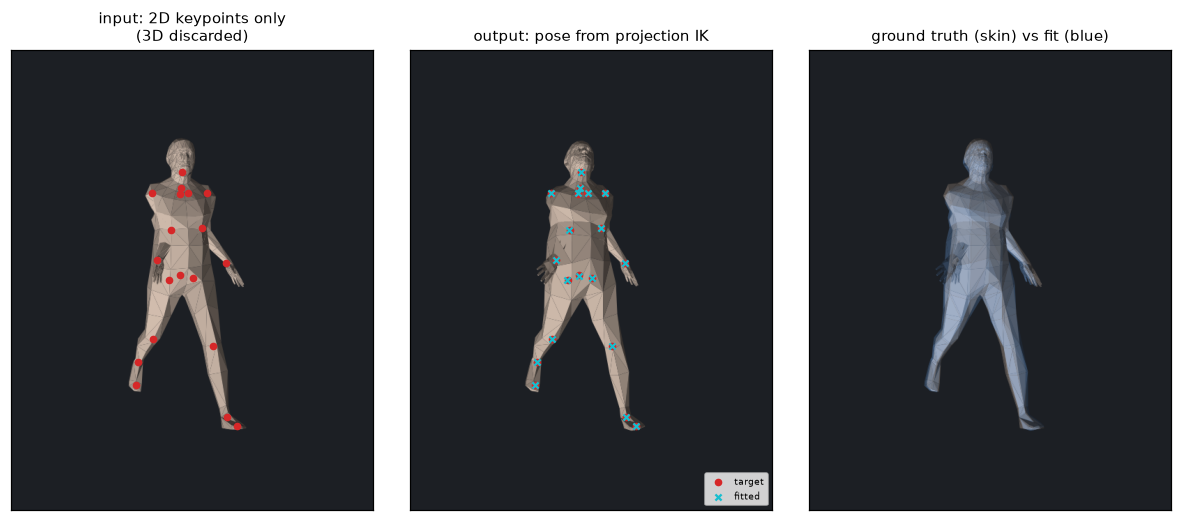

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(11, 4.6))
ax[0].imshow(render.render(verts_t[0].numpy(), faces(model), cam))
ax[0].scatter(*uv_obs.T, s=16, color="tab:red")
ax[0].set(title="input: 2D keypoints only\n(3D discarded)", xticks=[], yticks=[])

ax[1].imshow(render.render(verts_f[0].numpy(), faces(model), cam))
ax[1].scatter(*uv_obs.T, s=16, color="tab:red", label="target")
ax[1].scatter(*uv_fit.T, s=16, color="tab:cyan", marker="x", label="fitted")
ax[1].legend(fontsize=6, loc="lower right")
ax[1].set(title="output: pose from projection IK", xticks=[], yticks=[])

ax[2].imshow(np.clip(0.5 * render.render(verts_t[0].numpy(), faces(model), cam).astype(float)
                     + 0.5 * render.render(verts_f[0].numpy(), faces(model), cam,
                                           color=(0.45, 0.65, 0.9)).astype(float), 0, 255).astype(np.uint8))
ax[2].set(title="ground truth (skin) vs fit (blue)", xticks=[], yticks=[])
plt.tight_layout(); plt.show()

The solver **nails the pixels** (0.2 px, tighter than the 2 px of noise we injected) while the
3D pose is off by ~19 cm. That gap is the whole difficulty of monocular fitting, and it is worth
proving that it is a property of the *problem* rather than something you can tune away. Below we
strip degrees of freedom away and watch the 2D error stay tiny while the 3D error refuses to
collapse.

In [27]:
ablations = []
allpose = torch.as_tensor(ptransform.pose_parameters).clone()

no_flex = allpose.clone()
for i, name in enumerate(PARAMS):
    if name.endswith("_flexible"):
        no_flex[i] = False

no_detail = no_flex.clone()
for i, name in enumerate(PARAMS):
    if any(t in name for t in ("thumb", "index", "middle", "ring", "pinky",
                               "talocrural", "subtalar", "ball")):
        no_detail[i] = False

no_translation = allpose.clone()
for name in ("root_tx", "root_ty", "root_tz"):
    no_translation[P[name]] = False

no_root = no_translation.clone()
for name in ("root_rx", "root_ry", "root_rz"):
    no_root[P[name]] = False

print(f"{'active parameters':<34s} {'n':>4s} {'2D px':>7s} {'MPJPE':>8s} {'root dz':>9s}")
for label, mask in [("all 136 pose DoF", allpose),
                    ("no *_flexible residuals", no_flex),
                    ("no fingers / foot detail either", no_detail),
                    ("root translation locked", no_translation),
                    ("whole root locked (pose only)", no_root)]:
    theta = solve_2d(mask)
    px, mpjpe, dz = score(theta)
    print(f"{label:<34s} {int(mask.sum()):>4d} {px:>7.2f} {mpjpe:>7.2f}cm {dz:>+8.1f}cm")

active parameters                     n   2D px    MPJPE   root dz
all 136 pose DoF                    136    0.24   19.30cm    +34.1cm
no *_flexible residuals             110    1.13   18.96cm    +19.5cm
no fingers / foot detail either      54    0.91   21.56cm    +27.8cm
root translation locked             133    0.34   16.12cm     +0.0cm
whole root locked (pose only)       130    0.43   13.31cm     +0.0cm


Read that table carefully, because it is the single most useful thing in this notebook if you are
fitting to images:

* **Every row reprojects to well under a pixel.** The 2D residual tells you almost nothing about
  whether the 3D pose is right. Never report reprojection error as if it validated a fit.
* **Locking the root helps** (19 → 13 cm) because it removes the global scale–depth coupling: a
  body further away with longer-looking limbs projects identically.
* **Restricting the remaining DoF does not help.** ~13 cm of error survives with the root pinned
  and only 130 rotational DoF, because each individual limb can point towards or away from the
  camera and foreshorten to the same pixels. That is a genuine two-fold ambiguity per limb, not
  an optimiser failure.

The fixes are all about *adding information*, not constraining the solver harder:

| add | how, in this API |
|---|---|
| depth / point cloud | `ErrorFunctionType.Vertex` with `VertexConstraintType.Position`, or `Distance`/`Plane` terms |
| a second camera | more `Projection` constraints, different `proj` matrices, one solve |
| a learned pose prior | `ErrorFunctionType.PosePrior` with a `pymomentum.geometry.Mppca` model |
| temporal continuity | `pymomentum.solver2.solve_sequence` with velocity / acceleration terms |
| a floor | `solver2.FloorErrorFunction`, or `HeightErrorFunction` |

The depth column is exactly why the SynthHuman work in this workspace fits against depth rather
than pixels alone.

## 11. Cheat sheet

**The four arrows**

```
θ_p (204 named)  --T_p-->  Θ_j (127x7)  --FK-->  S (127x8 world)  --LBS-->  X (V x 3, cm)
   model_parameters(...)    ptransform.apply    model_parameters_to_       model(...)
                                                skeleton_state
```

**Layouts**

| object | shape | contents |
|---|---|---|
| model parameters | `(B, 204)` | named rig controls, radians; `root_t*` in units of 10 cm |
| joint parameters | `(127, 7)` | `tx ty tz rx ry rz s`, Euler XYZ, scale = $2^{s}$ |
| skeleton state | `(B, 127, 8)` | world `tx ty tz qx qy qz qw s` |
| vertices | `(B, V, 3)` | cm, +y up, +z forward, feet at y ≈ 0 |

**Local transform** — get this order wrong and nothing else works:

$$L_j = T(\mathrm{offset}_j + t_j)\cdot R^{\mathrm{pre}}_j \cdot R_{xyz}(r_j)\cdot S(2^{s_j}),
\qquad W_j = W_{\mathrm{parent}(j)} L_j$$

**Chain navigation**

```python
skeleton.joint_parents          # (127,) parent index, -1 at the root; parent always < child
skeleton.get_parent(j)          # walk up
skeleton.get_child_joints(j, recursive)   # walk down
skeleton.offsets                # (127, 3) rest bone vector in the parent frame, cm
skeleton.pre_rotations          # (127, 4) xyzw; aligns local x with the bone -> x is twist
character.parameter_limits      # 198 authored MinMax / ellipsoid limits
```

**Which parameters can move what**

```python
ptransform.parameters_for_joints([...])   # boolean mask -> feed straight to active_parameters
ptransform.pose_parameters               # 136 pose DoF
ptransform.scaling_parameters            # the scale_* / *_length_flexible block
ptransform.joints_for_parameters         # the other direction
```

**IK recipe**

```python
pms.solve_ik(
    character=character,
    active_parameters=mask,                        # ALWAYS restrict this
    model_parameters_init=theta0,                  # LM finds a local minimum: init matters
    active_error_functions=[pms.ErrorFunctionType.Position, pms.ErrorFunctionType.Limit],
    error_function_weights=torch.tensor([[1.0, 1.0]]),
    position_cons_parents=..., position_cons_offsets=...,
    position_cons_weights=..., position_cons_targets=...,
    options=pms.SolverOptions(max_iter=60, levmar_lambda=0.01),
)
```

Available error-function types: `Position`, `Orientation`, `Limit`, `Projection` (2D pixels),
`Distance`, `Motion` (stay near a target parameter vector — a temporal-smoothness or
regularisation term), `PosePrior` (mixture-PCA), `Vertex`, `VertexProjection`, `Collision`.
`pymomentum.solver2` exposes the same machinery as composable objects, plus `solve_sequence`
for solving a whole trajectory with velocity/acceleration/jerk terms across frames.

**Five things that will bite you**

1. **Scale is $2^s$**, not $s$ or $e^s$.
2. **Never leave `active_parameters` fully open.** 204 DoF against 3 equations means the solver
   leans the whole body to move a hand. Use `parameters_for_joints`.
3. **`root_tx/ty/tz` are in units of 10 cm** while everything else is cm.
4. **Include `ErrorFunctionType.Limit`** for anything you will render, or you will get
   hyperextended knees that reproject perfectly.
5. **The kinematics are LOD-independent.** Fit at LOD 4 or 6, evaluate at LOD 1 — the parameter
   vectors are identical, and the coarse model is 5–30× cheaper.